In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Linear regression

In this notebook, we will implement a solver for linear regression that uses the analytical solution.
The data is stored in the `data/icecream/` folder, and contains `X`, the temperature on a given day as well as `y`, the number of ice-creams sold by a shop on those days.

## Loading the data
The data in `npy` format can be loaded using `np.load`.

In [3]:
X = np.load('icecream/x.npy')
y = np.load('icecream/y.npy')

## Visualization

Let us inspect the data using a scatter plot.

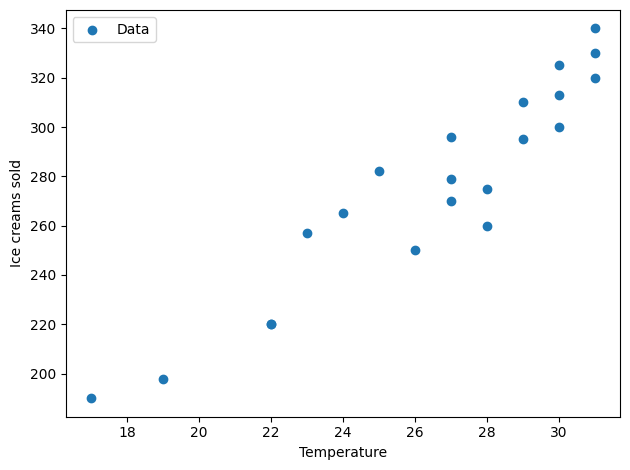

In [7]:
plt.scatter(X,y, label="Data")
plt.xlabel("Temperature")
plt.ylabel("Ice creams sold")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
print(f"The shape of X is {X.shape}, while the shape of y is {y.shape}")

The shape of X is (21, 1), while the shape of y is (21, 1)


We would like to find coefficients $\theta_d \in \mathbb{R}^{D+1}$, such that we can express `y` in terms of `X`, assuming a linear relationship.

Complete the function so that (i) we add a column of ones for the bias term and (ii) we use the analytical solution explained in the lecture for finding $\theta$.

In [12]:
def find_coefficients(X,y):
    ones = np.ones((X.shape[0], 1))
    # Variante 1: mit np.hstack
    X_new = np.hstack((ones, X)) 
    thetas = np.linalg.inv(X_new.T @ X_new) @ X_new.T @ y
    return thetas

In [13]:
coeffs = find_coefficients(X,y)

print(coeffs)

[[11.10076606]
 [10.00338833]]


Next, we need a function to evaluate the linear regression given new data. This function should (i) add a column of ones, and (ii) evaluate the regression

In [15]:
def eval_linear_regression(X, coeffs):
    ones = np.ones((X.shape[0], 1))
    # Variante 1: mit np.hstack
    X_new = np.hstack((ones, X)) 
    return X_new @ coeffs

In [16]:
y_pred = eval_linear_regression(X, coeffs)

Finally, let us visualize the output

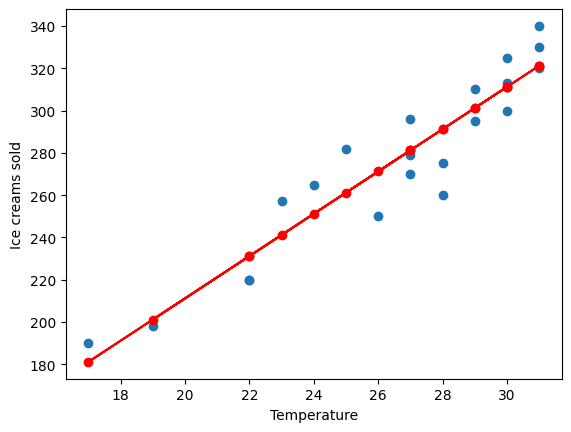

In [18]:
plt.scatter(X, y) # original data
plt.scatter(X, eval_linear_regression(X, find_coefficients(X, y)), color='r') # regression - points
plt.plot(X, eval_linear_regression(X, find_coefficients(X, y)), color='r') # regression - as line

plt.xlabel("Temperature")
plt.ylabel("Ice creams sold")
plt.show()